In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [6]:
df=pd.read_csv("../data/loan_data.csv")
print("dataset loaded successfully")


dataset loaded successfully


In [7]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
print("rows:",df.shape[0])
print("columns:",df.shape[1])

rows: 614
columns: 13


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
df.describe(include='object')

C:\Users\Siddhi\AppData\Local\Temp\ipykernel_26476\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [12]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Credit_History       8.143322
Self_Employed        5.211726
LoanAmount           3.583062
Dependents           2.442997
Loan_Amount_Term     2.280130
Gender               2.117264
Married              0.488599
Education            0.000000
Loan_ID              0.000000
CoapplicantIncome    0.000000
ApplicantIncome      0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [16]:
df['Loan_Status'].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

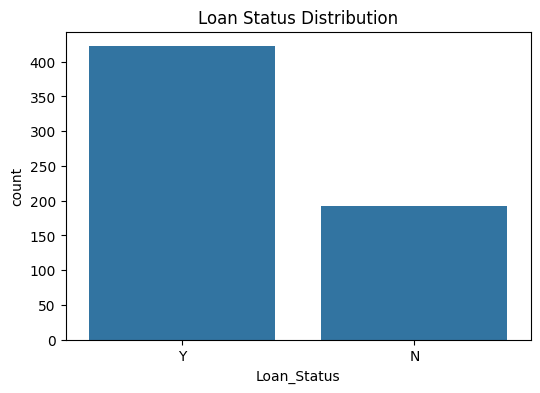

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='Loan_Status',
    data=df
)

plt.title("Loan Status Distribution")

plt.show()

In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns

numerical_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical Features:")
print(categorical_cols)

print("\nNumerical Features:")
print(numerical_cols)

Categorical Features:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='str')

Numerical Features:
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')


C:\Users\Siddhi\AppData\Local\Temp\ipykernel_26476\3094191963.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [19]:
print("="*50)

print("DATASET SUMMARY")

print("="*50)

print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nLoan Status Distribution:")
print(df['Loan_Status'].value_counts())

print("="*50)

DATASET SUMMARY
Shape: (614, 13)

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicate Rows:
0

Loan Status Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


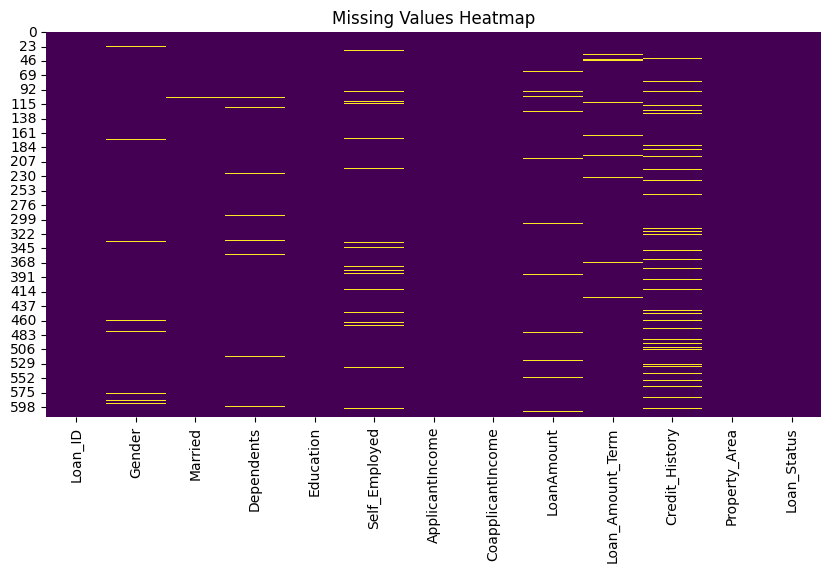

In [20]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

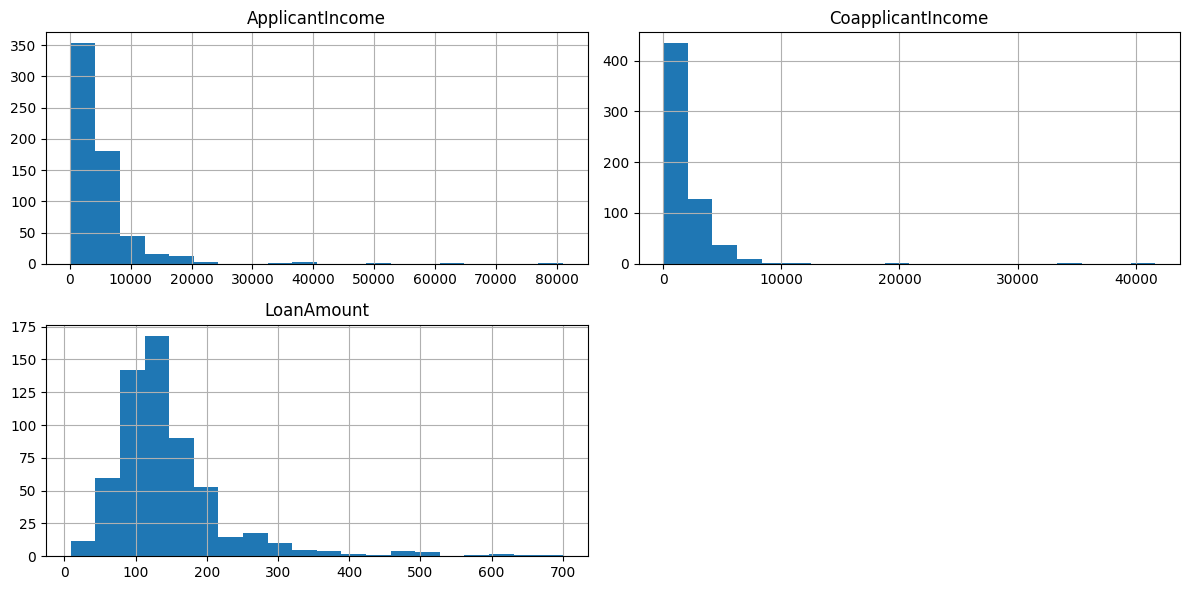

In [21]:
numerical_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount'
]

df[numerical_cols].hist(
    figsize=(12,6),
    bins=20
)

plt.tight_layout()
plt.show()

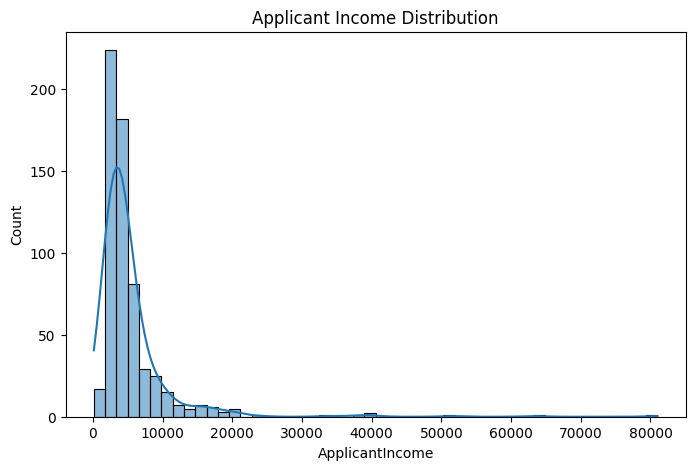

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['ApplicantIncome'],
    kde=True
)

plt.title("Applicant Income Distribution")
plt.show()


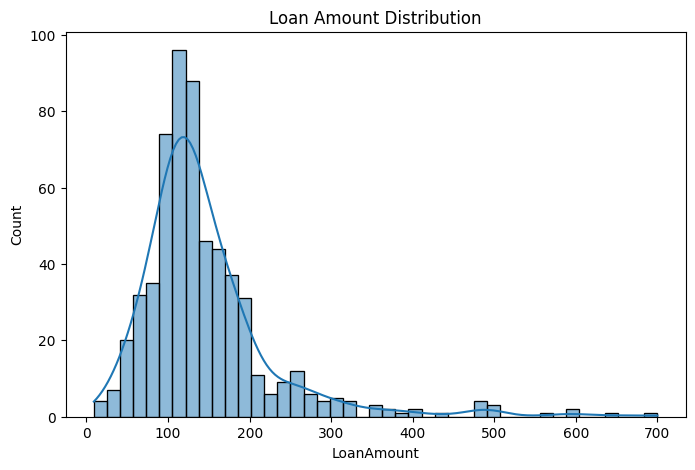

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LoanAmount'],
    kde=True
)

plt.title("Loan Amount Distribution")
plt.show()

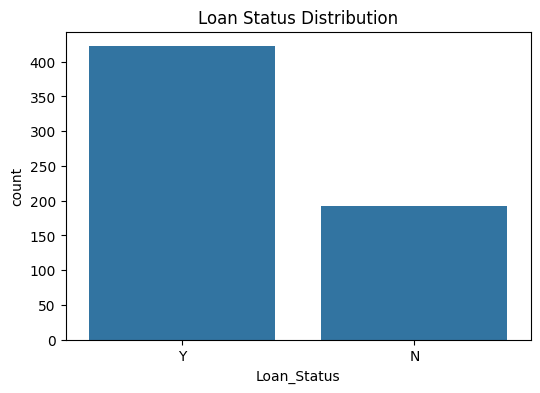

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Loan_Status',
    data=df
)

plt.title("Loan Status Distribution")
plt.show()

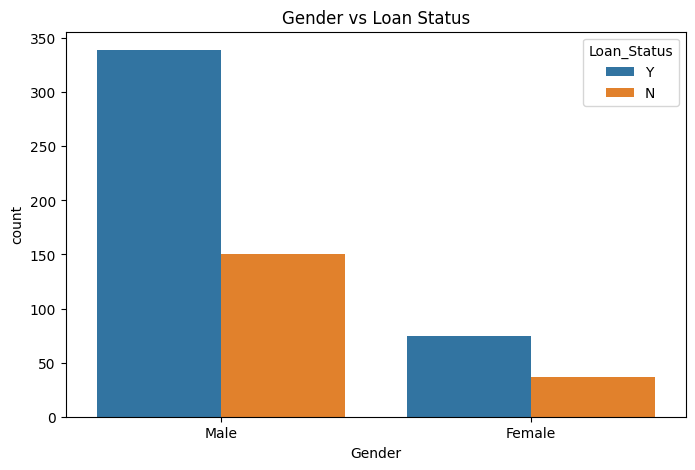

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    hue='Loan_Status',
    data=df
)

plt.title("Gender vs Loan Status")
plt.show()

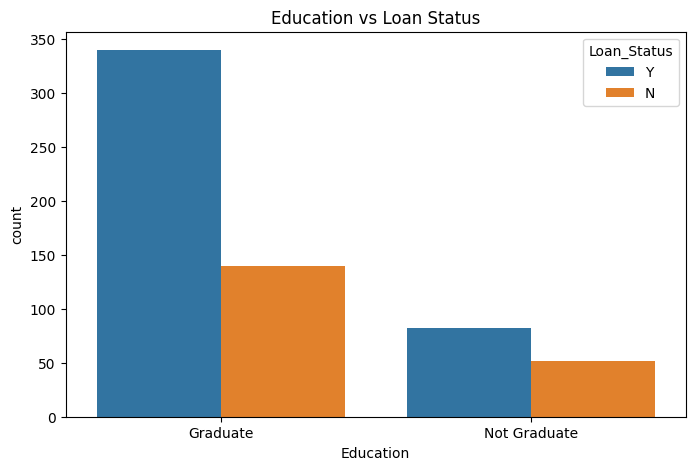

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Education',
    hue='Loan_Status',
    data=df
)

plt.title("Education vs Loan Status")
plt.show()

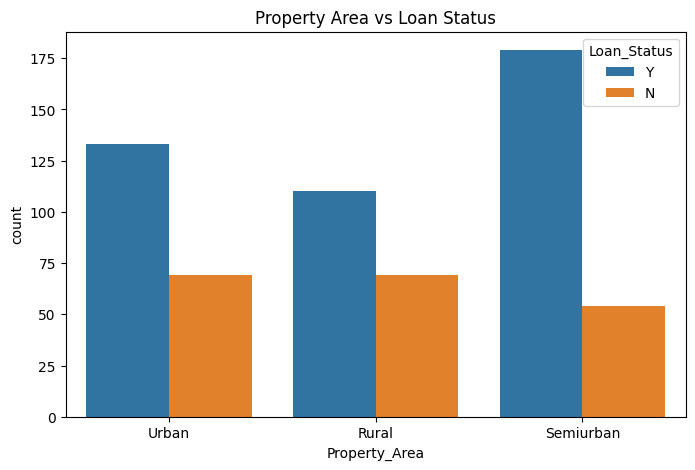

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Property_Area',
    hue='Loan_Status',
    data=df
)

plt.title("Property Area vs Loan Status")
plt.show()

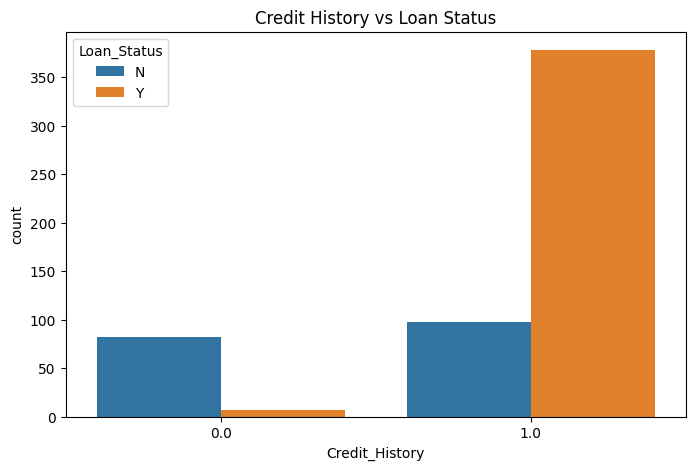

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df
)

plt.title("Credit History vs Loan Status")
plt.show()

In [29]:
eda_df=df.copy()

eda_df['Loan_Status'] = eda_df['Loan_Status'].map({
    'Y':1,
    'N':0
})

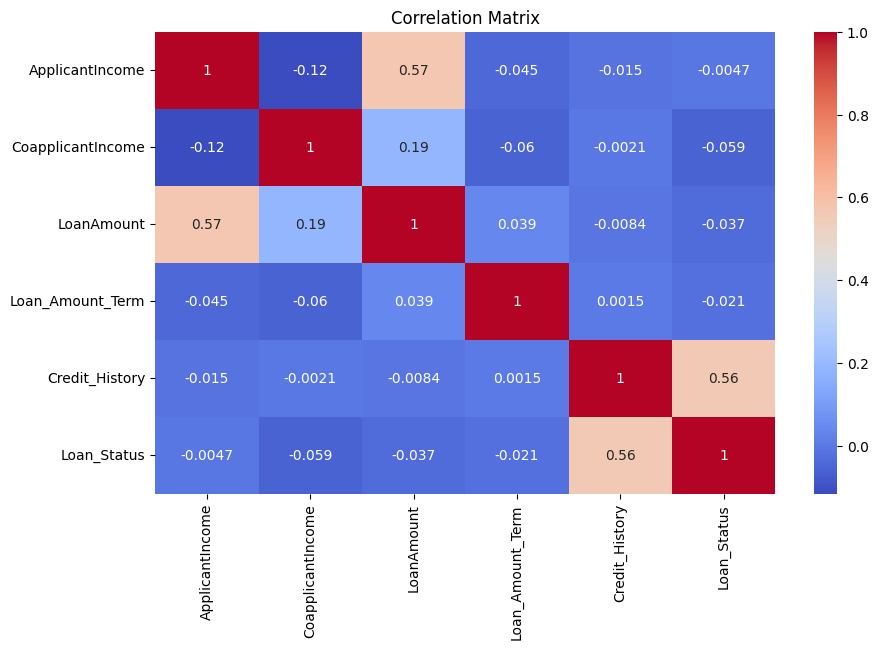

In [30]:
numeric_df = eda_df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

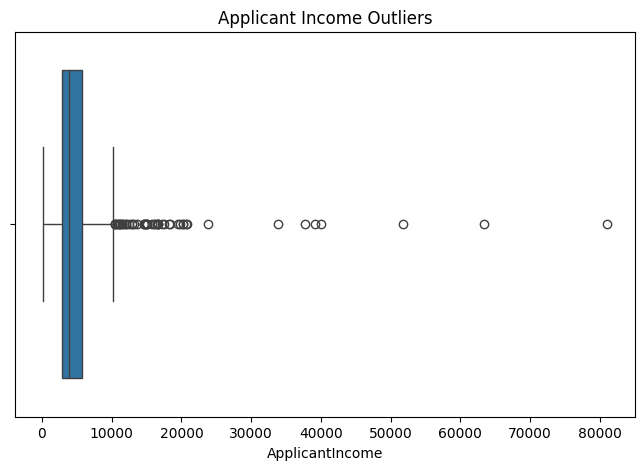

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['ApplicantIncome']
)

plt.title("Applicant Income Outliers")
plt.show()

## Key Insights

1. Applicant Income is highly right-skewed.
2. Loan Amount contains outliers.
3. Credit History strongly influences loan approval.
4. Most loans are approved.
5. Property Area shows moderate impact on approval.
6. Missing values are present and require preprocessing.

In [72]:
df_processed = df.copy()

In [73]:
df_processed.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [74]:
df_processed['Gender'].fillna(
    df_processed['Gender'].mode()[0],
    inplace=True
)

df_processed['Married'].fillna(
    df_processed['Married'].mode()[0],
    inplace=True
)

df_processed['Dependents'].fillna(
    df_processed['Dependents'].mode()[0],
    inplace=True
)

df_processed['Self_Employed'].fillna(
    df_processed['Self_Employed'].mode()[0],
    inplace=True
)

C:\Users\Siddhi\AppData\Local\Temp\ipykernel_26476\1500247454.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_processed['Gender'].fillna(
C:\Users\Siddhi\AppData\Local\Temp\ipykernel_26476\1500247454.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplac

0       No
1       No
2      Yes
3       No
4       No
      ... 
609     No
610     No
611     No
612     No
613    Yes
Name: Self_Employed, Length: 614, dtype: str

In [75]:
df_processed['LoanAmount'].fillna(
    df_processed['LoanAmount'].median(),
    inplace=True
)

df_processed['Loan_Amount_Term'].fillna(
    df_processed['Loan_Amount_Term'].median(),
    inplace=True
)

df_processed['Credit_History'].fillna(
    df_processed['Credit_History'].mode()[0],
    inplace=True
)

C:\Users\Siddhi\AppData\Local\Temp\ipykernel_26476\874694242.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_processed['LoanAmount'].fillna(
C:\Users\Siddhi\AppData\Local\Temp\ipykernel_26476\874694242.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inpl

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64

In [76]:
df_processed.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [77]:
df_processed = df.copy()

In [78]:
df_processed['Gender'] = df_processed['Gender'].fillna(df_processed['Gender'].mode()[0])

df_processed['Married'] = df_processed['Married'].fillna(df_processed['Married'].mode()[0])

df_processed['Dependents'] = df_processed['Dependents'].fillna(df_processed['Dependents'].mode()[0])

df_processed['Self_Employed'] = df_processed['Self_Employed'].fillna(df_processed['Self_Employed'].mode()[0])

In [79]:
df_processed['LoanAmount'] = df_processed['LoanAmount'].fillna(df_processed['LoanAmount'].median())

df_processed['Loan_Amount_Term'] = df_processed['Loan_Amount_Term'].fillna(df_processed['Loan_Amount_Term'].median())

df_processed['Credit_History'] = df_processed['Credit_History'].fillna(df_processed['Credit_History'].mode()[0])

In [80]:
df_processed.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [81]:
df_processed['TotalIncome'] = (
    df_processed['ApplicantIncome']
    +
    df_processed['CoapplicantIncome']
)

In [82]:
df_processed[['ApplicantIncome','CoapplicantIncome','TotalIncome']].head()

,ApplicantIncome,CoapplicantIncome,TotalIncome
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [83]:
df_processed['LoanIncomeRatio'] = (
    df_processed['LoanAmount']
    /
    df_processed['TotalIncome']
)

In [84]:
import numpy as np

df_processed['LogIncome'] = np.log1p(
    df_processed['TotalIncome']
)

In [85]:
df_processed.drop(
    'Loan_ID',
    axis=1,
    inplace=True
)

In [86]:
df_processed['Loan_Status'] = (
    df_processed['Loan_Status']
    .map({
        'Y':1,
        'N':0
    })
)

In [87]:
df_processed['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [88]:
df_processed = pd.get_dummies(
    df_processed,
    drop_first=True
)

In [89]:
df_processed.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanIncomeRatio,LogIncome,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,5849.0,0.021884,8.674197,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,6091.0,0.021015,8.714732,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,3000.0,0.022000,8.006701,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,4941.0,0.024287,8.505525,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,6000.0,0.023500,8.699681,True,False,False,False,False,False,False,False,True


In [90]:
X = df_processed.drop(
    'Loan_Status',
    axis=1
)

y = df_processed['Loan_Status']

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [93]:
from sklearn.preprocessing import StandardScaler

In [94]:
scaler = StandardScaler()

In [95]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [96]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(491, 17)
(123, 17)


In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [98]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [99]:
lr_model.fit(
    X_train_scaled,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [100]:
y_pred = lr_model.predict(
    X_test_scaled
)

In [101]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 78.05 %


Phase 5: Decision Tree

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [103]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, dt_pred)
)

Decision Tree Accuracy: 0.6991869918699187


Phase 6: Random Forest

In [104]:
from sklearn.ensemble import RandomForestClassifier

In [105]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [106]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [107]:
rf_pred = rf_model.predict(X_test)

In [108]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.7886178861788617


In [109]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.79      0.53      0.64        43
           1       0.79      0.93      0.85        80

    accuracy                           0.79       123
   macro avg       0.79      0.73      0.74       123
weighted avg       0.79      0.79      0.78       123



Phase 7: Feature Importance


In [110]:
import pandas as pd

In [111]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

In [112]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [113]:
feature_importance.head(10)

,Feature,Importance
4,Credit_History,0.247031
6,LoanIncomeRatio,0.120036
5,TotalIncome,0.109905
7,LogIncome,0.101810
0,ApplicantIncome,0.099745
2,LoanAmount,0.099182
1,CoapplicantIncome,0.061585
3,Loan_Amount_Term,0.034496
15,Property_Area_Semiurban,0.023829
9,Married_Yes,0.017346


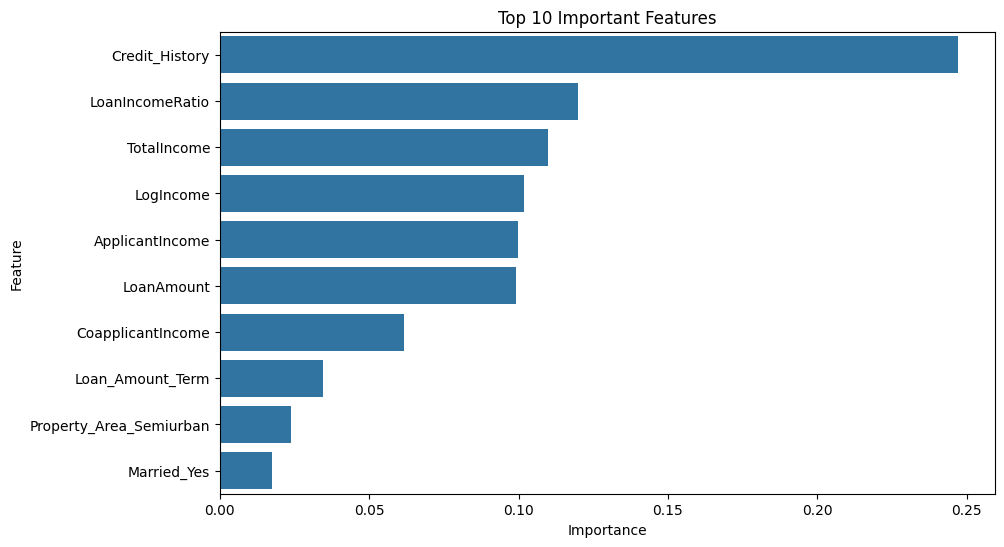

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

Phase 8: XGBoost

In [115]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 19.1 MB/s eta 0:00:06
   - -------------------------------------- 4.7/101.7 MB 12.6 MB/s eta 0:00:08
   -- ------------------------------------- 5.8/101.7 MB 10.2 MB/s eta 0:00:10
   -- ------------------------------------- 7.1/101.7 MB 8.4 MB/s eta 0:00:12
   --- ------------------------------------ 7.9/101.7 MB 7.6 MB/s eta 0:00:13
   --- ------------------------------------ 8.4/101.7 MB 6.7 MB/s eta 0:00:14
   --- ------------------------------------ 8.9/101.7 MB 6.1 MB/s eta 0:00:16
   --- ------------------------------------ 9.4/101.7 MB 5.6 MB/s eta 0:00:17
   --- ------------------------------------ 10.0/101.7 MB 5.3 MB/s eta 0:00:18
   ---- ----------------------------------- 10.5/101.7 MB 5.0 MB/s eta 0:00:19
   ---- ----------------------------------- 11.0/101.7 MB 4.8 MB/s eta 0:


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
from xgboost import XGBClassifier

In [117]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [118]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [119]:
xgb_pred = xgb_model.predict(
    X_test
)

In [120]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost Accuracy:",
    xgb_accuracy
)

XGBoost Accuracy: 0.7479674796747967


Phase 9: Model Comparision Table

In [121]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy,
        accuracy_score(y_test, dt_pred),
        rf_accuracy,
        xgb_accuracy
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.788618
0,Logistic Regression,0.780488
3,XGBoost,0.747967
1,Decision Tree,0.699187


Phase 10: Cross Validation

In [122]:
from sklearn.model_selection import cross_val_score

In [123]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

In [124]:
print(
    "Average CV Score:",
    cv_scores.mean()
)

Average CV Score: 0.7964147674263626


Phase 11: Save Best Model

In [125]:
import joblib

In [127]:
joblib.dump(
    xgb_model,
    "../models/loan_default_model.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/loan_default_model.pkl'